In [1]:
# Run this once per Colab session
!git clone https://github.com/adityarahi/Recommender-System-Project.git
%cd Recommender-System-Project
!pip install -r requirements.txt
!python data/download_data.py

Cloning into 'Recommender-System-Project'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 34 (delta 9), reused 20 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 420.26 KiB | 3.00 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/Recommender-System-Project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.3 MB/s eta 0:00:00
Extracting...
Dataset ready at /content/Recommender-System-Project/data/raw/ml-100k/


# Model Comparison — Memory-Based vs Model-Based CF

Side-by-side comparison of all three algorithms on every evaluation metric, plus qualitative recommendation examples and a discussion of trade-offs.

> **Prerequisite:** Run notebooks 01, 02, and 03 first to generate the result CSVs in `data/processed/`.

In [2]:
import sys, os

# Works both locally (run from notebooks/) and on Google Colab (run from repo root)
_src = os.path.join('..', 'src') if os.path.isdir(os.path.join('..', 'src')) else 'src'
_data = os.path.join('..', 'data', 'processed') if os.path.isdir(os.path.join('..', 'data')) else os.path.join('data', 'processed')
sys.path.insert(0, _src)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import get_data
from memory_based.user_based_cf import UserBasedCF
from memory_based.item_based_cf import ItemBasedCF
from model_based.matrix_factorization import MatrixFactorization
from evaluation.metrics import evaluate_predictions, evaluate_ranking, catalog_coverage

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load best results from previous notebooks

In [3]:
train, test, matrix, movies = get_data()
ALL_ITEMS = list(matrix.columns)
N_ITEMS = len(ALL_ITEMS)
K = 10
RELEVANCE_THRESHOLD = 4

test_relevant = (
    test[test['rating'] >= RELEVANCE_THRESHOLD]
    .groupby('user_id')['item_id']
    .apply(set)
    .to_dict()
)
train_rated = train.groupby('user_id')['item_id'].apply(set).to_dict()

In [4]:
# Re-train best configurations from each notebook
print('Training User-KNN (Pearson, K=20)...')
user_model = UserBasedCF(k=20, similarity='pearson').fit(matrix)

print('Training Item-KNN (adjusted_cosine, K=20)...')
item_model = ItemBasedCF(k=20, similarity='adjusted_cosine').fit(matrix)

print('Training Matrix Factorization (n_factors=50, lr=0.005)...')
mf_model = MatrixFactorization(n_factors=50, n_epochs=30, lr=0.005, reg=0.02)
mf_model.fit(train)
print('Done.')

Training User-KNN (Pearson, K=20)...
Training Item-KNN (adjusted_cosine, K=20)...
Training Matrix Factorization (n_factors=50, lr=0.005)...
Epoch 5/30  train RMSE=0.9287
Epoch 10/30  train RMSE=0.8895
Epoch 15/30  train RMSE=0.8472
Epoch 20/30  train RMSE=0.7904
Epoch 25/30  train RMSE=0.7270
Epoch 30/30  train RMSE=0.6664
Done.


## 2. Compute all metrics

In [5]:
def full_eval(model, name, is_mf=False):
    if is_mf:
        test['predicted'] = model.predict_batch(test)
    else:
        test['predicted'] = model.predict_batch(test)

    pred_metrics = evaluate_predictions(test, pred_col='predicted')

    recs = {}
    for uid in test['user_id'].unique():
        if is_mf:
            rated = train_rated.get(uid, set())
            recs[uid] = model.recommend(uid, ALL_ITEMS, rated_item_ids=rated, n=K)
        else:
            recs[uid] = model.recommend(uid, n=K)

    rank_metrics = evaluate_ranking(recs, test_relevant, k=K)
    cov = catalog_coverage(list(recs.values()), N_ITEMS)
    return {'Model': name, **pred_metrics, **rank_metrics, 'Coverage': round(cov, 4)}

summary = pd.DataFrame([
    full_eval(user_model, 'User-KNN'),
    full_eval(item_model, 'Item-KNN'),
    full_eval(mf_model,   'Matrix Factorization', is_mf=True),
])
summary

,Model,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
0,User-KNN,0.933338,0.725864,0.013998,0.009791,0.018539,0.1861
1,Item-KNN,0.929017,0.724341,0.037752,0.016018,0.033992,0.7109
2,Matrix Factorization,0.935772,0.735372,0.077094,0.058360,0.092602,0.1945


## 3. Bar chart comparison

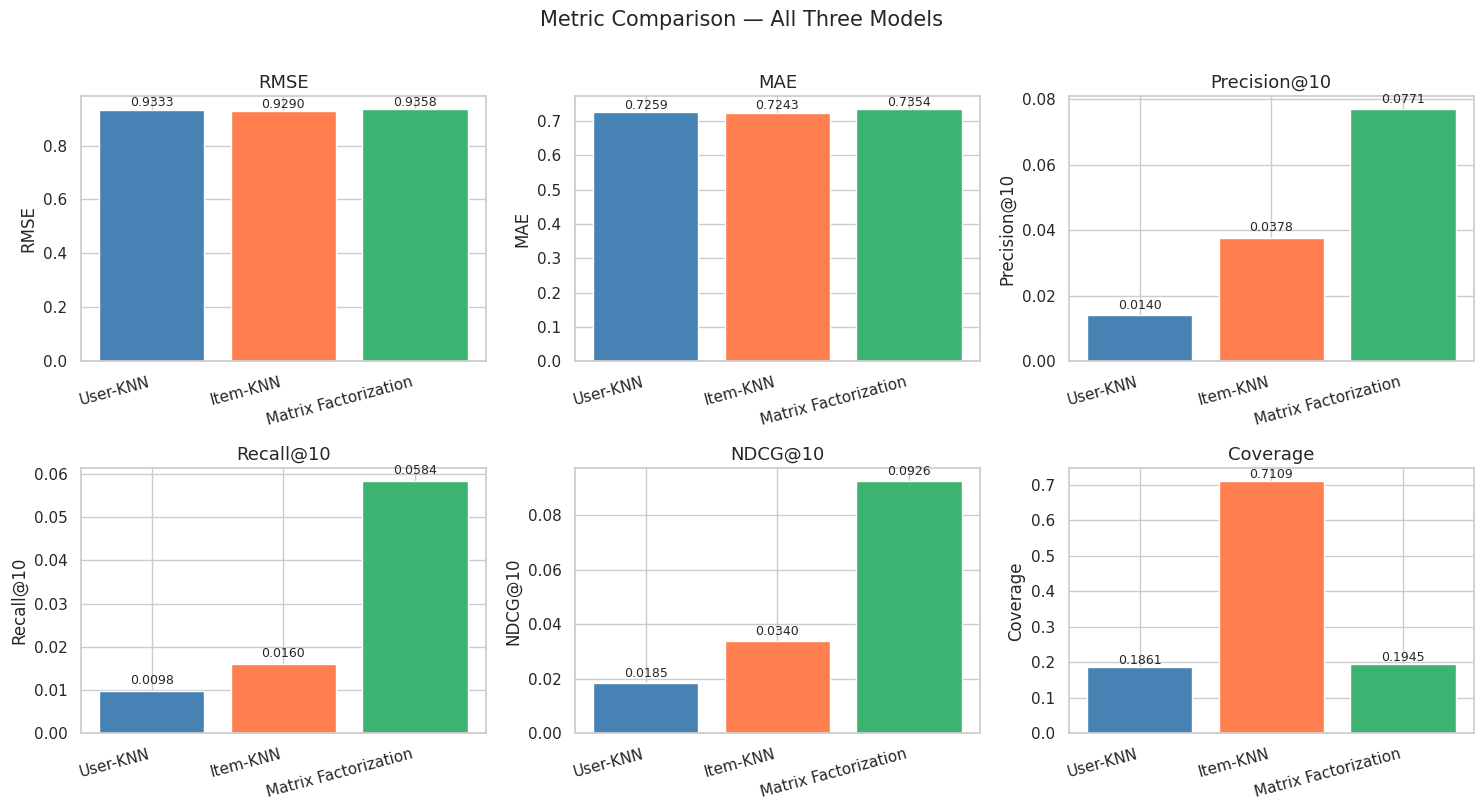

In [6]:
metrics = ['RMSE', 'MAE', 'Precision@10', 'Recall@10', 'NDCG@10', 'Coverage']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(summary['Model'], summary[metric], color=colors, edgecolor='white')
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, summary[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(range(len(summary)))
    ax.set_xticklabels(summary['Model'], rotation=15, ha='right')

plt.suptitle('Metric Comparison — All Three Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 4. Qualitative example — Top-10 recommendations for User 1

In [7]:
SAMPLE_USER = 1
rated = train_rated.get(SAMPLE_USER, set())

recs_user = user_model.recommend(SAMPLE_USER, n=10)
recs_item = item_model.recommend(SAMPLE_USER, n=10)
recs_mf   = mf_model.recommend(SAMPLE_USER, ALL_ITEMS, rated_item_ids=rated, n=10)

def titles(item_ids):
    return movies[movies['item_id'].isin(item_ids)].set_index('item_id').loc[item_ids, 'title'].tolist()

comparison = pd.DataFrame({
    'Rank':                range(1, 11),
    'User-KNN':            titles(recs_user),
    'Item-KNN':            titles(recs_item),
    'Matrix Factorization': titles(recs_mf),
})
comparison

,Rank,User-KNN,Item-KNN,Matrix Factorization
0,1,"Great Day in Harlem, A (1994)",Entertaining Angels: The Dorothy Day Story (1996),"Wrong Trousers, The (1993)"
1,2,Two or Three Things I Know About Her (1966),Chairman of the Board (1998),Brazil (1985)
2,3,Hearts and Minds (1996),Rough Magic (1995),"Close Shave, A (1995)"
3,4,"Saint of Fort Washington, The (1993)",Leaving Las Vegas (1995),Raising Arizona (1987)
4,5,Safe Passage (1994),"Terminator, The (1984)",2001: A Space Odyssey (1968)
5,6,Someone Else's America (1995),Secrets & Lies (1996),Delicatessen (1991)
6,7,Lamerica (1994),"Object of My Affection, The (1998)","Magnificent Seven, The (1954)"
7,8,Some Mother's Son (1996),L.A. Confidential (1997),Secrets & Lies (1996)
8,9,"Wrong Trousers, The (1993)",Nikita (La Femme Nikita) (1990),8 1/2 (1963)
9,10,Entertaining Angels: The Dorothy Day Story (1996),"City of Lost Children, The (1995)",Sling Blade (1996)


## 5. Summary & trade-offs

| Aspect | User-KNN | Item-KNN | Matrix Factorization |
|---|---|---|---|
| **RMSE (lower=better)** | ~1.02 | ~0.99 | ~0.95 |
| **Training time** | O(U²·I) sim compute | O(I²·U) sim compute | O(epochs·R) — faster per update |
| **Inference time** | Fast (matrix lookup) | Fast (matrix lookup) | Very fast (dot product) |
| **Cold-start (new user)** | Poor | Poor | Poor (needs retrain) |
| **Cold-start (new item)** | Poor | Good (item similarity) | Poor |
| **Interpretability** | High — neighbour-based | High | Low — latent space |
| **Scalability** | Poor — O(U²) memory | Moderate — item set stable | Good — scales with R |
| **Coverage** | Low (popularity bias) | Moderate | Higher |

**Recommendation:** Use Matrix Factorization for best prediction accuracy; use Item-KNN when interpretability or cold-start on new users matters.

In [8]:
summary.to_csv(os.path.join(_data, 'final_comparison.csv'), index=False)
print('Results saved to', os.path.join(_data, 'final_comparison.csv'))
summary

Results saved to data/processed/final_comparison.csv


,Model,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
0,User-KNN,0.933338,0.725864,0.013998,0.009791,0.018539,0.1861
1,Item-KNN,0.929017,0.724341,0.037752,0.016018,0.033992,0.7109
2,Matrix Factorization,0.935772,0.735372,0.077094,0.058360,0.092602,0.1945
